# 05 -- Outlier Detection (Visual + Statistical)

**Pichle steps ka recap:**
- `01`-`03`: Raw SEC data load, join, pivot -> `final_ml_ready_dataset.parquet` (currency-fixed + duration-fixed, `03` v3)
- `04`: Duplicates hataye, transition-reports flag, delinquent-filers flag, invalid
  negative values NaN -> `04_cleaned_dataset.parquet`

**ZAROORI DESIGN DECISION (empirical testing se pata chala):**
Is notebook mein sirf DETECTION hoti hai (aur EPS ki genuine data-errors fix hoti
hain) -- raw dollar-columns (Assets, Liabilities, Revenues, NetIncomeLoss...) ko
CAP/WINSORIZE **nahi** kiya jata.

**Wajah (proof ke saath):** JPMorgan Chase ki TRUE Assets $3.9 trillion hain. Agar
hum isay 99th-percentile par cap kar dete ($214 billion), to `08` mein jab ROA
(NetIncome / Assets) banega, to ye CAPPED Assets se banega -- jisse JPMorgan ka
ROA asal se **lagbhag 18 guna zyada (GALAT)** dikhega (Assets ko 3.9T se 214B karne ka multiple). Ye industry-standard
financial-modeling practice ke khilaf hai -- raw dollar-figures kabhi truncate
nahi kiye jate, sirf RATIOS (jo already scale-independent hain) winsorize hote hain.

**Isliye:**
- Legitimate extreme values (JPMorgan ki bari Assets, Boeing ka bara loss) --
  sirf FLAG hongi yahan. Treatment (capping) `08` mein, RATIOS banne ke BAAD hogi.
- EPS ki genuine DATA ERRORS (jaise $108 million/share -- XBRL tagging bug) --
  ABHI yahan fix hongi (NaN), kyunki EPS khud kisi doosre ratio ka denominator
  nahi banta, isliye ise fix karne se cross-contamination ka khatra nahi hai.

**Is notebook ka structure:**
1. **Visual Methods (2)** -- Box plots + Histograms, saare 22 columns
   -> `reports/figures/outliers_detection_visual_charts/`
2. **Statistical Methods (2)** -- Sign-Split IQR + Sign-Split Modified Z-score
   -> `reports/figures/outliers_detection_statistical_charts/`
3. **EPS error-correction** (implausible values -> NaN)
4. Save -> `05_outliers_flagged.parquet` (raw dollar-values UNCHANGED,
   sirf flag-columns aur EPS-fix add hue)

## Working directory fix (zaroori)

In [1]:
import os
from pathlib import Path

if not Path("data").exists():
    os.chdir("..")

print("Working directory:", os.getcwd())
assert Path("data/processed").exists(), "data/processed nahi mila -- path check karo"

Working directory: d:\Developing_Projects\cross-industry-financial-analysis_Project


## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

PROCESSED_DIR = Path("data/processed")
VISUAL_DIR = Path("reports/figures/outliers_detection_visual_charts")
STATISTICAL_DIR = Path("reports/figures/outliers_detection_statistical_charts")
VISUAL_DIR.mkdir(parents=True, exist_ok=True)
STATISTICAL_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = PROCESSED_DIR / "04_cleaned_dataset.parquet"
OUTPUT_PATH = PROCESSED_DIR / "05_outliers_flagged.parquet"

ID_COLS = ["adsh", "cik", "name", "sic", "form", "period", "fy", "fp", "filed", "source_quarter"]
NON_METRIC_FLAG_COLS = ["is_transition_report", "is_timely_filer", "filing_delay_days"]

# EPS ke liye: |value| > 1000 genuinely IMPOSSIBLE hai kisi real company ke liye
EPS_PLAUSIBILITY_LIMIT = 1000
EPS_COLS = ["EarningsPerShareBasic", "EarningsPerShareDiluted"]

sns.set_style("whitegrid")
print(f"Visual charts -> {VISUAL_DIR}")
print(f"Statistical charts -> {STATISTICAL_DIR}")

Visual charts -> reports\figures\outliers_detection_visual_charts
Statistical charts -> reports\figures\outliers_detection_statistical_charts


## Load 04 ka output

In [3]:
df = pd.read_parquet(INPUT_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (58241, 35)


,adsh,cik,name,sic,form,period,fy,fp,filed,source_quarter,...,NetIncomeLoss,OperatingIncomeLoss,ResearchAndDevelopmentExpense,RevenueFromContractWithCustomerExcludingAssessedTax,Revenues,SellingGeneralAndAdministrativeExpense,StockholdersEquity,is_transition_report,filing_delay_days,is_timely_filer
0,0000090168-23-000083,90168,SIFCO INDUSTRIES INC,3724,10-K,2023-09-30,2023,FY,2024-01-02,2024q1,...,-2173000.0,-1683250.0,NaN,21755500.0,NaN,3507250.0,34335000.0,False,94,True
1,0001213900-24-000266,1696355,BRIGHT SCHOLAR EDUCATION HOLDINGS LTD,8200,20-F,2023-08-31,2023,FY,2024-01-02,2024q1,...,-13610000.0,-6426500.0,NaN,NaN,73150000.0,21258250.0,195174000.0,False,124,False
2,0001437749-24-000191,832489,"GEOVAX LABS, INC.",2834,S-1,2023-09-30,2023,Q3,2024-01-02,2024q1,...,-8408818.0,-8599754.0,6947979.0,NaN,NaN,NaN,9119346.0,False,94,True
3,0001493152-24-000094,1782309,SKILLFUL CRAFTSMAN EDUCATION TECHNOLOGY LTD,8200,6-K,2023-09-30,2024,Q2,2024-01-02,2024q1,...,-183486.5,-402358.5,NaN,NaN,NaN,NaN,25606228.0,False,94,True
4,0001493152-24-000139,1879293,"MAG MILE CAPITAL, INC.",3567,10-QT,2023-07-31,2023,Q3,2024-01-02,2024q1,...,-1368359.5,-1365751.0,NaN,NaN,NaN,NaN,710469.0,True,155,False


In [4]:
metric_cols = [c for c in df.columns if c not in ID_COLS and c not in NON_METRIC_FLAG_COLS]
print(f"Metric columns ({len(metric_cols)}):")
metric_cols

Metric columns (22):


['Assets',
 'AssetsCurrent',
 'CashAndCashEquivalentsAtCarryingValue',
 'CostOfRevenue',
 'EarningsPerShareBasic',
 'EarningsPerShareDiluted',
 'GrossProfit',
 'IncomeTaxExpenseBenefit',
 'InventoryNet',
 'Liabilities',
 'LiabilitiesCurrent',
 'LongTermDebtNoncurrent',
 'NetCashProvidedByUsedInFinancingActivities',
 'NetCashProvidedByUsedInInvestingActivities',
 'NetCashProvidedByUsedInOperatingActivities',
 'NetIncomeLoss',
 'OperatingIncomeLoss',
 'ResearchAndDevelopmentExpense',
 'RevenueFromContractWithCustomerExcludingAssessedTax',
 'Revenues',
 'SellingGeneralAndAdministrativeExpense',
 'StockholdersEquity']

## Helper functions

1. `make_grid` -- dynamic subplot grid (saare 22 columns ke liye)
2. `detect_outliers_iqr_signsplit` -- STATISTICAL METHOD 1 (sign-split IQR)
3. `detect_outliers_modzscore_signsplit` -- STATISTICAL METHOD 2 (sign-split
   Modified Z-score -- median/MAD based, robust)
4. `signlog` -- sirf VISUALIZATION ke liye

**Reminder (jo humne pehle test kiya tha):** Simple combined sign-log + IQR
13 out of 22 columns mein pathological results deta tha (kabhi 100% negative
values wholesale flag, kabhi 0% detection). Sign-split fix ye masla solve karta
hai -- positive aur negative values ka IQR/Z-score ALAG-ALAG nikal kar.

In [5]:
def make_grid(n_plots, cols=5):
    rows = math.ceil(n_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3.5 * rows))
    axes = axes.flatten()
    for ax in axes[n_plots:]:
        ax.axis("off")
    return fig, axes


def detect_outliers_iqr_signsplit(series: pd.Series) -> pd.Series:
    """STATISTICAL METHOD 1: IQR, positive aur negative values ALAG-ALAG."""
    result = pd.Series(False, index=series.index)
    pos, neg = series[series > 0], series[series < 0]

    if len(pos) >= 10:
        t = np.log1p(pos)
        q1, q3 = t.quantile(0.25), t.quantile(0.75)
        iqr = q3 - q1
        mask = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
        result.loc[pos.index[mask]] = True

    if len(neg) >= 10:
        t = -np.log1p(-neg)
        q1, q3 = t.quantile(0.25), t.quantile(0.75)
        iqr = q3 - q1
        mask = (t < q1 - 1.5 * iqr) | (t > q3 + 1.5 * iqr)
        result.loc[neg.index[mask]] = True

    return result


def detect_outliers_modzscore_signsplit(series: pd.Series, threshold: float = 3.5) -> pd.Series:
    """STATISTICAL METHOD 2: Modified Z-score (median/MAD), positive/negative ALAG-ALAG."""
    result = pd.Series(False, index=series.index)
    pos, neg = series[series > 0], series[series < 0]

    for subset, transform in [(pos, np.log1p), (neg, lambda x: -np.log1p(-x))]:
        if len(subset) < 10:
            continue
        t = transform(subset)
        median = t.median()
        mad = (t - median).abs().median()
        if mad == 0:
            continue
        modified_z = 0.6745 * (t - median) / mad
        mask = modified_z.abs() > threshold
        result.loc[subset.index[mask]] = True

    return result


def signlog(series):
    """Sirf VISUALIZATION ke liye -- combined sign-log (chart-shape dikhane ke liye)."""
    return np.sign(series) * np.log1p(np.abs(series))

print("Functions ready.")

Functions ready.


---
# PART 1 -- Visual Methods (saare 22 columns)
### (charts `outliers_detection_visual_charts/` folder mein save hongi)

## Visual Method 1 -- Box Plots (log-scale)

`showfliers=False` -- default outlier-diamond-marking is sign-mixed data ke liye
misleading hoti hai (jaisa humne test kiya), isliye sirf box+whiskers (shape context)
dikha rahe hain, outlier-marking statistical section mein karenge.

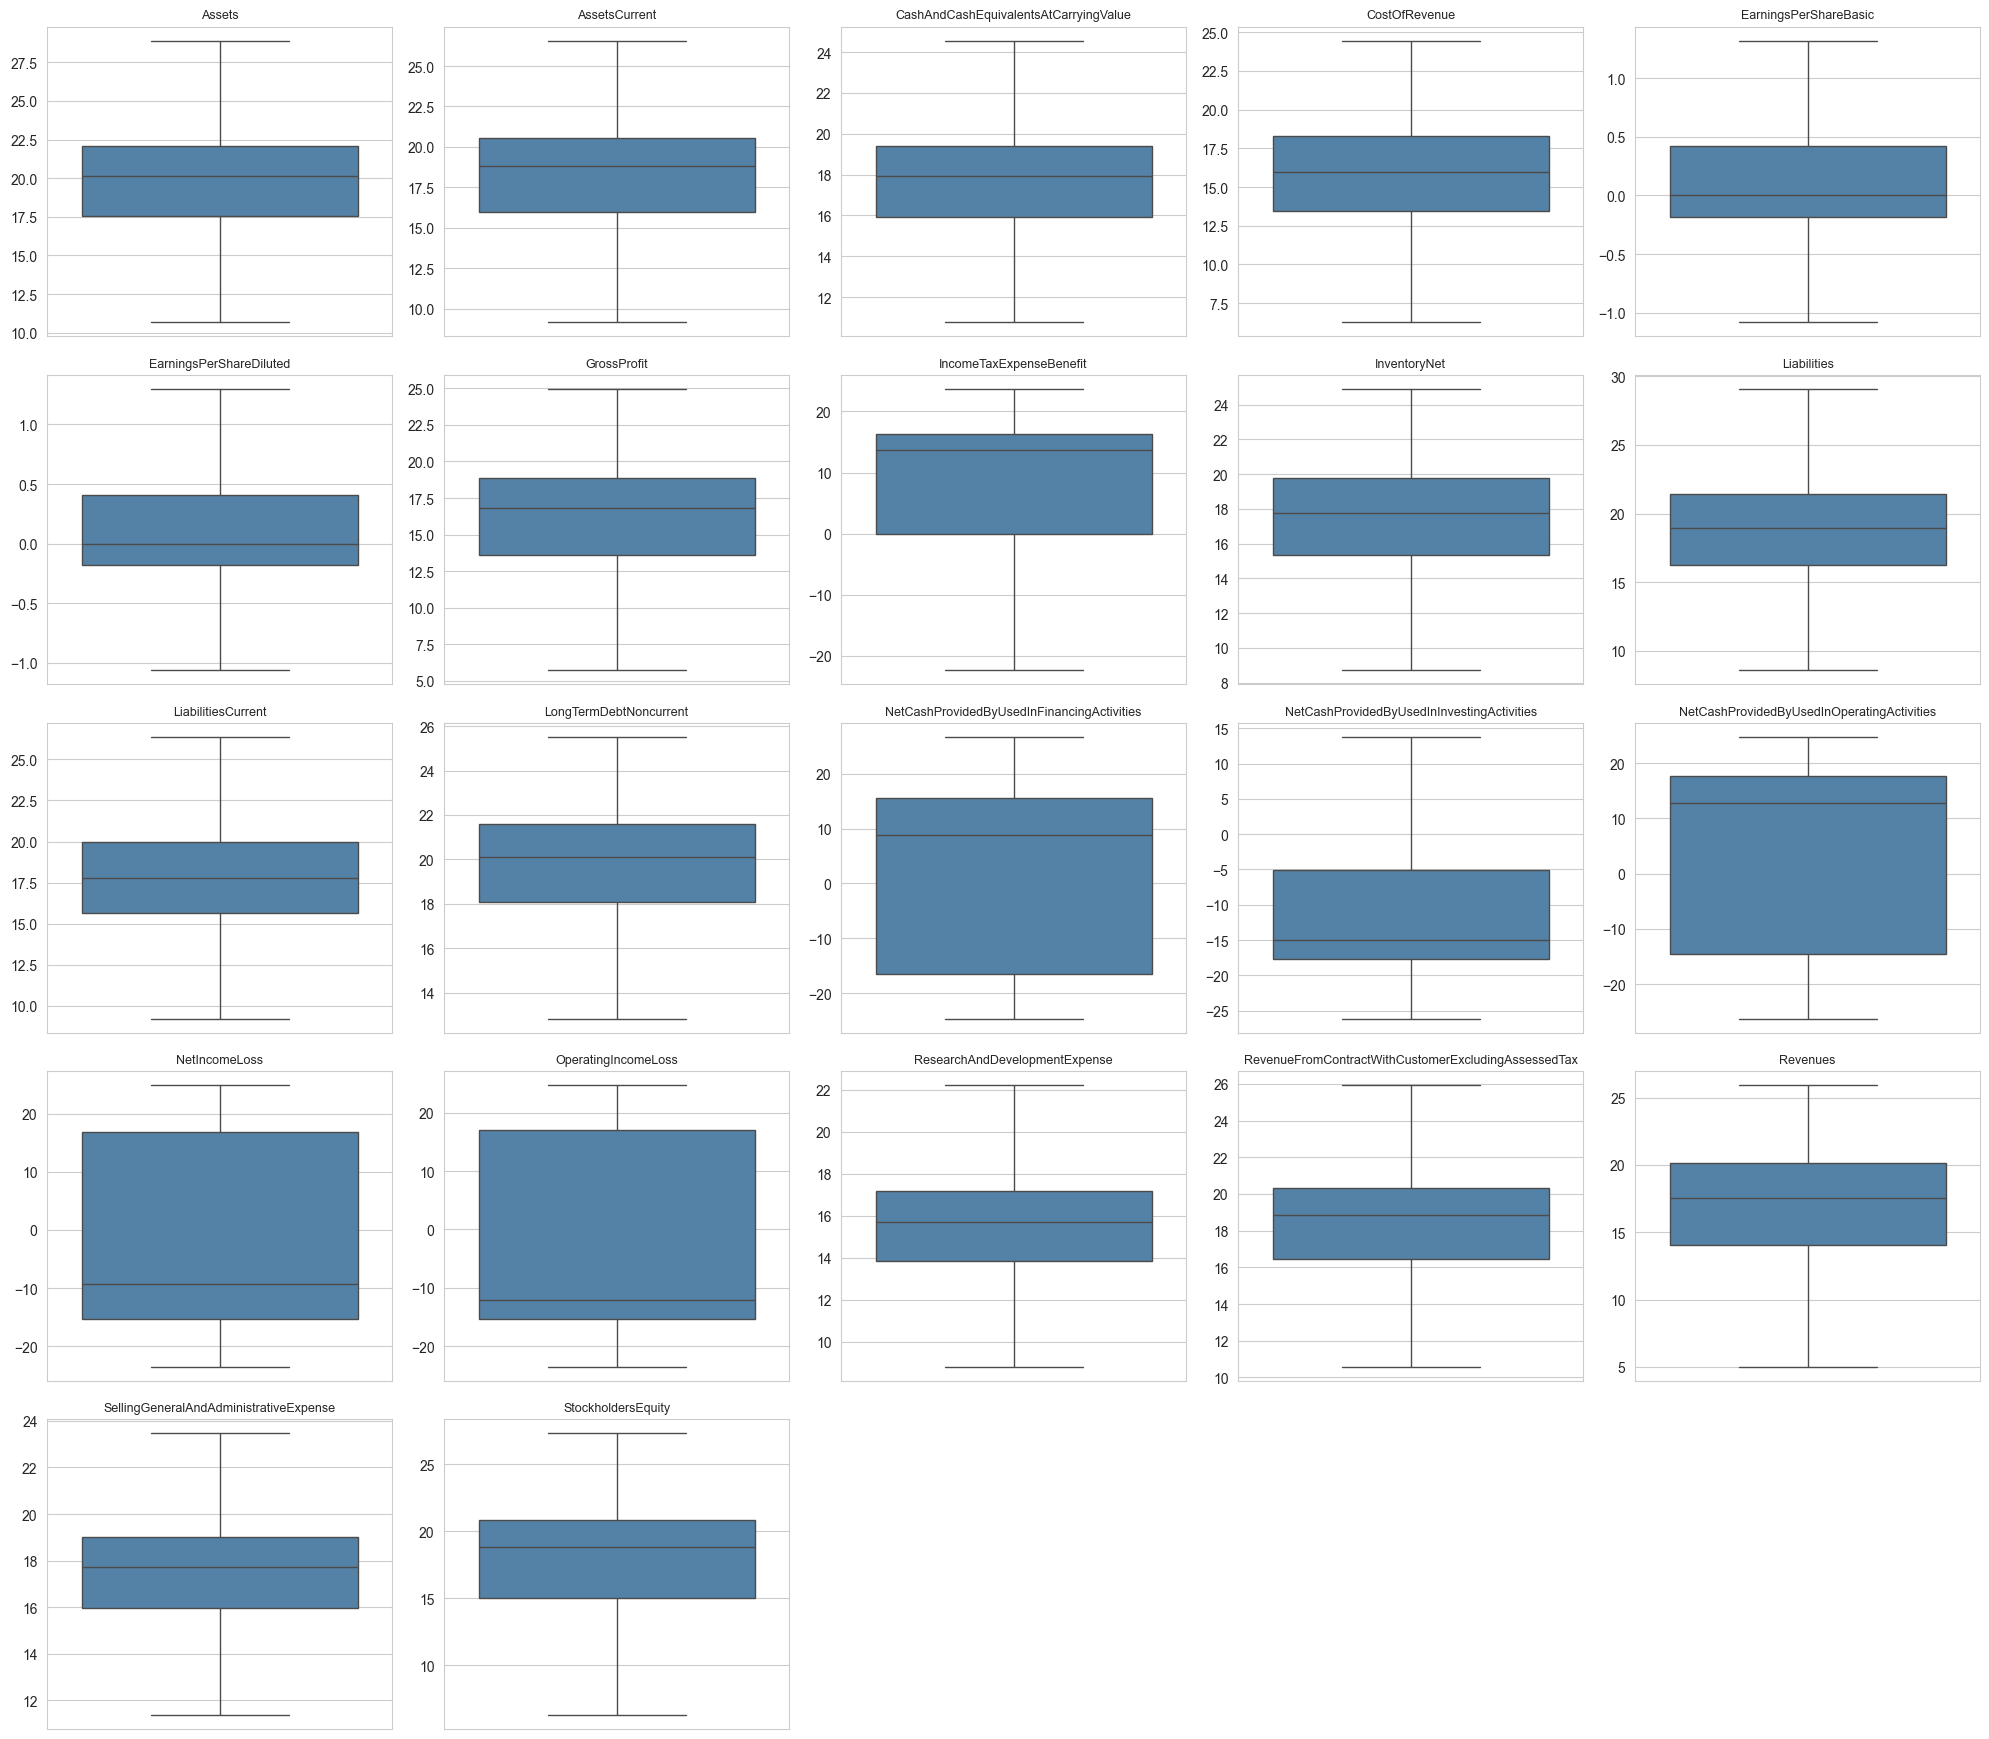

[SAVED] reports\figures\outliers_detection_visual_charts\01_boxplots_all_metrics.png  (saare 22 columns)


In [6]:
fig, axes = make_grid(len(metric_cols), cols=5)
for ax, col in zip(axes, metric_cols):
    data = df[col].dropna()
    transformed = signlog(data)
    sns.boxplot(y=transformed, ax=ax, color="steelblue", showfliers=False)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(VISUAL_DIR / "01_boxplots_all_metrics.png", dpi=120)
plt.show()
print(f"[SAVED] {VISUAL_DIR / '01_boxplots_all_metrics.png'}  (saare {len(metric_cols)} columns)")

## Visual Method 2 -- Distribution Plots / Histograms (log-scale)

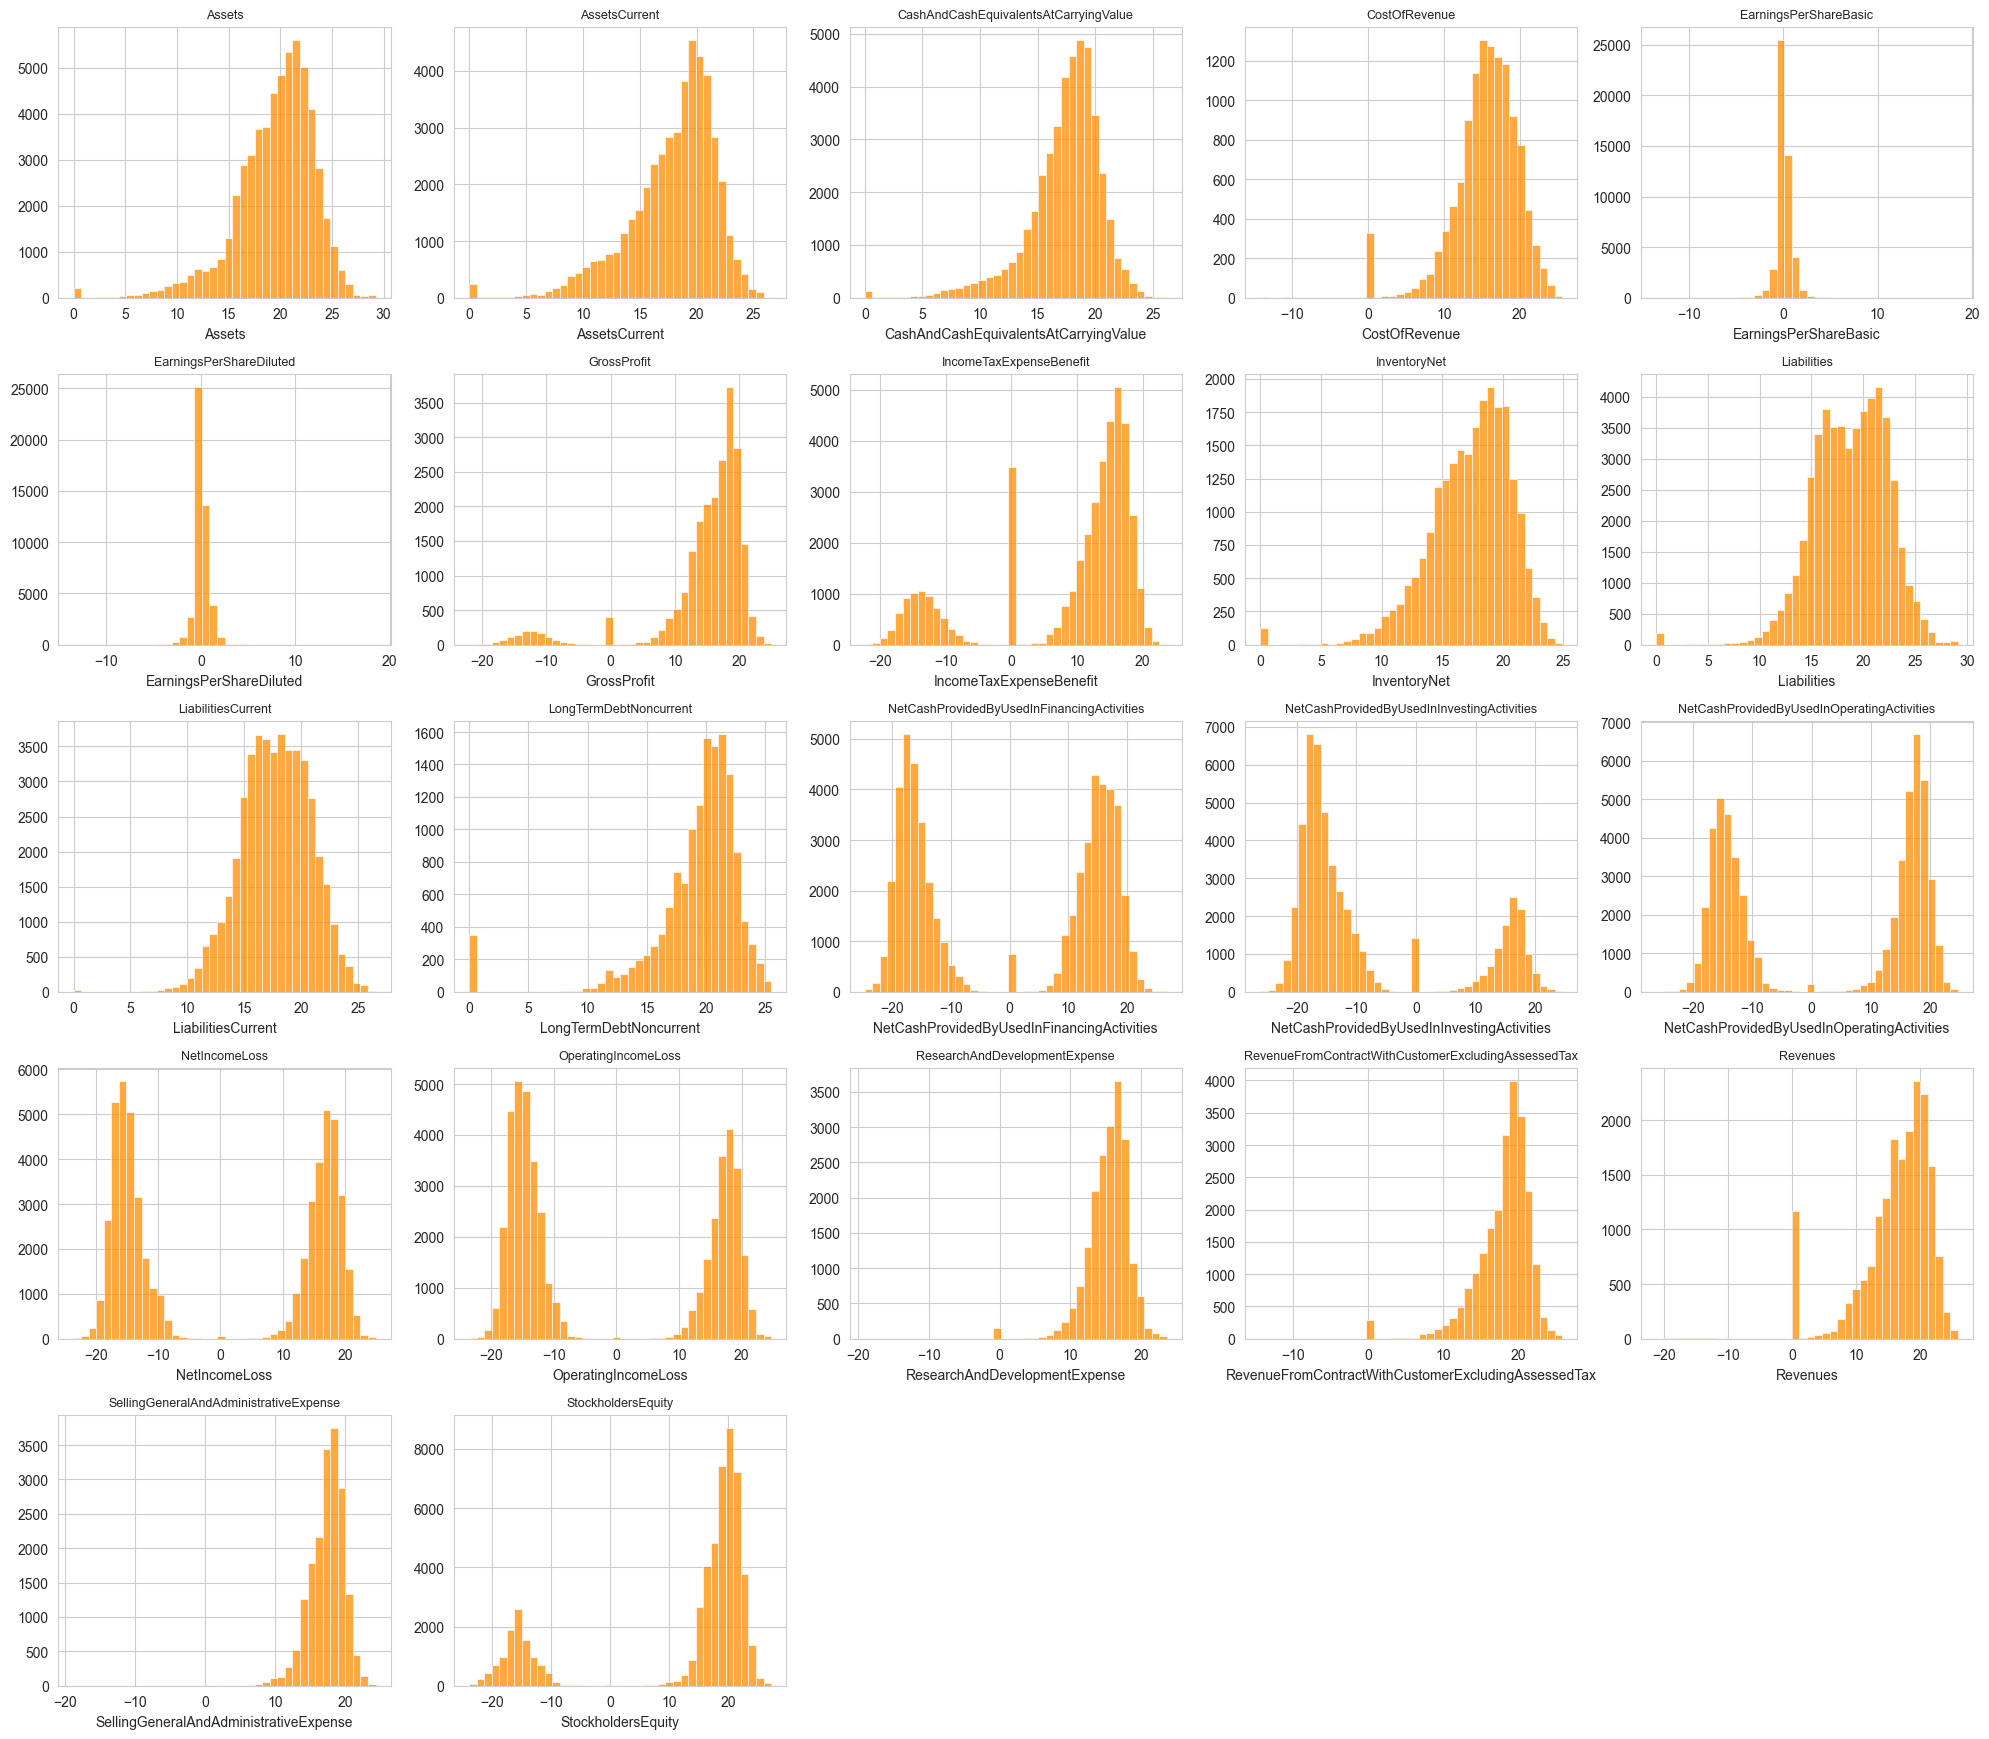

[SAVED] reports\figures\outliers_detection_visual_charts\02_distributions_all_metrics.png  (saare 22 columns)


In [7]:
fig, axes = make_grid(len(metric_cols), cols=5)
for ax, col in zip(axes, metric_cols):
    data = df[col].dropna()
    transformed = signlog(data)
    sns.histplot(transformed, ax=ax, bins=40, color="darkorange")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")

plt.tight_layout()
plt.savefig(VISUAL_DIR / "02_distributions_all_metrics.png", dpi=120)
plt.show()
print(f"[SAVED] {VISUAL_DIR / '02_distributions_all_metrics.png'}  (saare {len(metric_cols)} columns)")

---
# PART 2 -- Statistical Methods (saare 22 columns)
### (charts `outliers_detection_statistical_charts/` folder mein save hongi)

## Statistical Method 1 -- Sign-Split IQR

In [8]:
outlier_counts_iqr = {}
print("Statistical Method 1: Sign-Split IQR\n")
for col in metric_cols:
    mask = detect_outliers_iqr_signsplit(df[col])
    df[f"{col}_is_outlier_iqr"] = mask
    n = mask.sum()
    n_valid = df[col].notna().sum()
    outlier_counts_iqr[col] = n / n_valid if n_valid else 0
    print(f"  {col:55s} {n:6d} ({outlier_counts_iqr[col]:5.2%})")

Statistical Method 1: Sign-Split IQR

  Assets                                                    1394 (2.41%)
  AssetsCurrent                                             1107 (2.41%)
  CashAndCashEquivalentsAtCarryingValue                     1872 (4.31%)
  CostOfRevenue                                              130 (1.09%)
  EarningsPerShareBasic                                     2711 (5.57%)
  EarningsPerShareDiluted                                   2539 (5.35%)
  GrossProfit                                                258 (1.16%)
  IncomeTaxExpenseBenefit                                    362 (0.88%)
  InventoryNet                                               218 (0.95%)
  Liabilities                                                117 (0.23%)
  LiabilitiesCurrent                                         163 (0.36%)
  LongTermDebtNoncurrent                                     458 (3.29%)
  NetCashProvidedByUsedInFinancingActivities                 625 (1.15%)
  NetCashProv

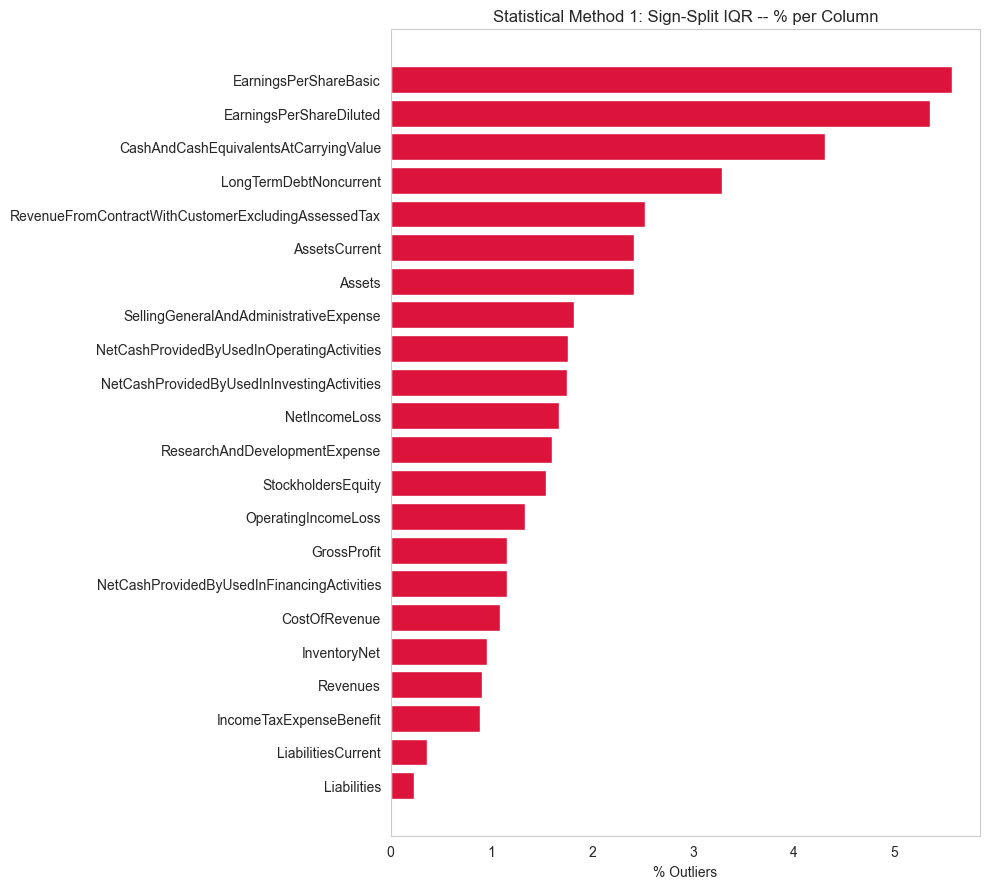

[SAVED] reports\figures\outliers_detection_statistical_charts\01_iqr_outlier_pct.png


In [16]:
fig, ax = plt.subplots(figsize=(10, 9))
s = pd.Series(outlier_counts_iqr).sort_values()
ax.barh(s.index, s.values * 100, color="crimson")
ax.set_xlabel("% Outliers")
ax.set_title("Statistical Method 1: Sign-Split IQR -- % per Column")
plt.tight_layout()
plt.grid(False)
plt.savefig(STATISTICAL_DIR / "01_iqr_outlier_pct.png", dpi=120)
plt.show()
print(f"[SAVED] {STATISTICAL_DIR / '01_iqr_outlier_pct.png'}")

## Statistical Method 2 -- Sign-Split Modified Z-score

In [10]:
outlier_counts_modz = {}
print("Statistical Method 2: Sign-Split Modified Z-score\n")
for col in metric_cols:
    mask = detect_outliers_modzscore_signsplit(df[col])
    df[f"{col}_is_outlier_modz"] = mask
    n = mask.sum()
    n_valid = df[col].notna().sum()
    outlier_counts_modz[col] = n / n_valid if n_valid else 0
    print(f"  {col:55s} {n:6d} ({outlier_counts_modz[col]:5.2%})")

Statistical Method 2: Sign-Split Modified Z-score

  Assets                                                     552 (0.95%)
  AssetsCurrent                                              476 (1.04%)
  CashAndCashEquivalentsAtCarryingValue                     1069 (2.46%)
  CostOfRevenue                                               28 (0.23%)
  EarningsPerShareBasic                                     2676 (5.50%)
  EarningsPerShareDiluted                                   2485 (5.23%)
  GrossProfit                                                100 (0.45%)
  IncomeTaxExpenseBenefit                                     69 (0.17%)
  InventoryNet                                                42 (0.18%)
  Liabilities                                                 23 (0.04%)
  LiabilitiesCurrent                                          15 (0.03%)
  LongTermDebtNoncurrent                                     238 (1.71%)
  NetCashProvidedByUsedInFinancingActivities                 126 (0.23%)


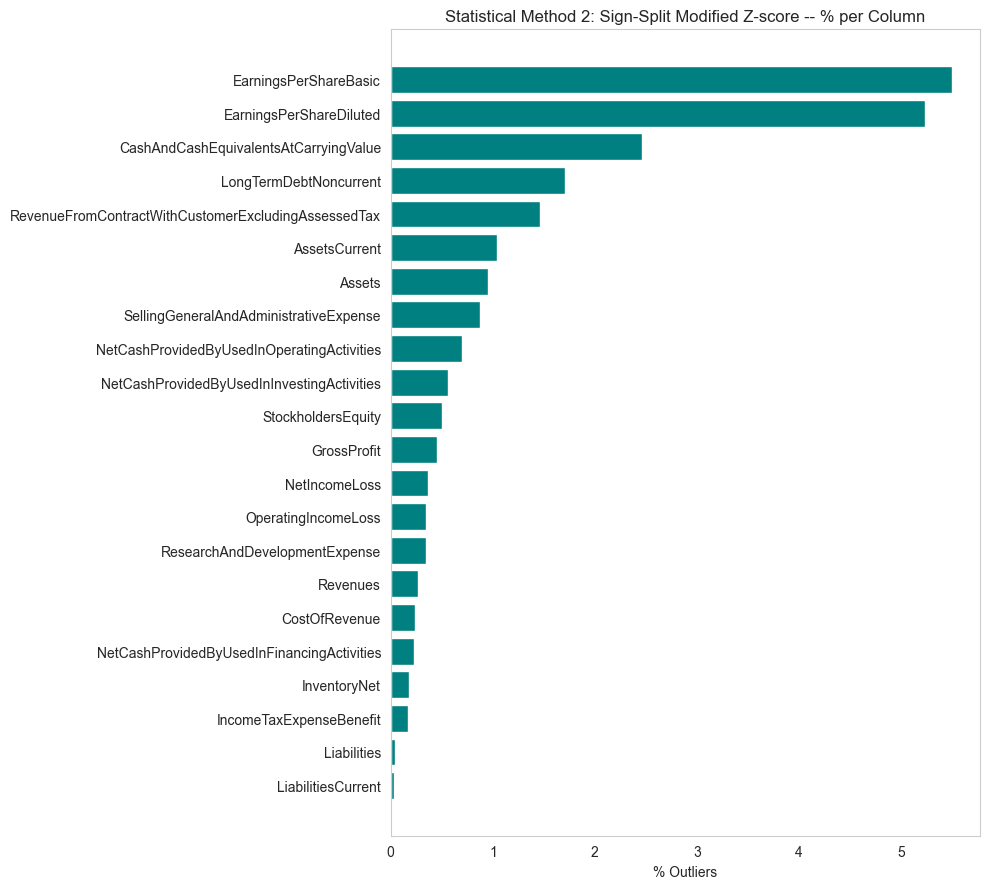

[SAVED] reports\figures\outliers_detection_statistical_charts\02_modzscore_outlier_pct.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 9))
s = pd.Series(outlier_counts_modz).sort_values()
ax.barh(s.index, s.values * 100, color="teal")
ax.set_xlabel("% Outliers")
ax.set_title("Statistical Method 2: Sign-Split Modified Z-score -- % per Column")
plt.tight_layout()
plt.grid(False)
plt.savefig(STATISTICAL_DIR / "02_modzscore_outlier_pct.png", dpi=120)
plt.show()
print(f"[SAVED] {STATISTICAL_DIR / '02_modzscore_outlier_pct.png'}")

---
# PART 3 -- Cross-Check: Visual vs Statistical (saare 22 columns)

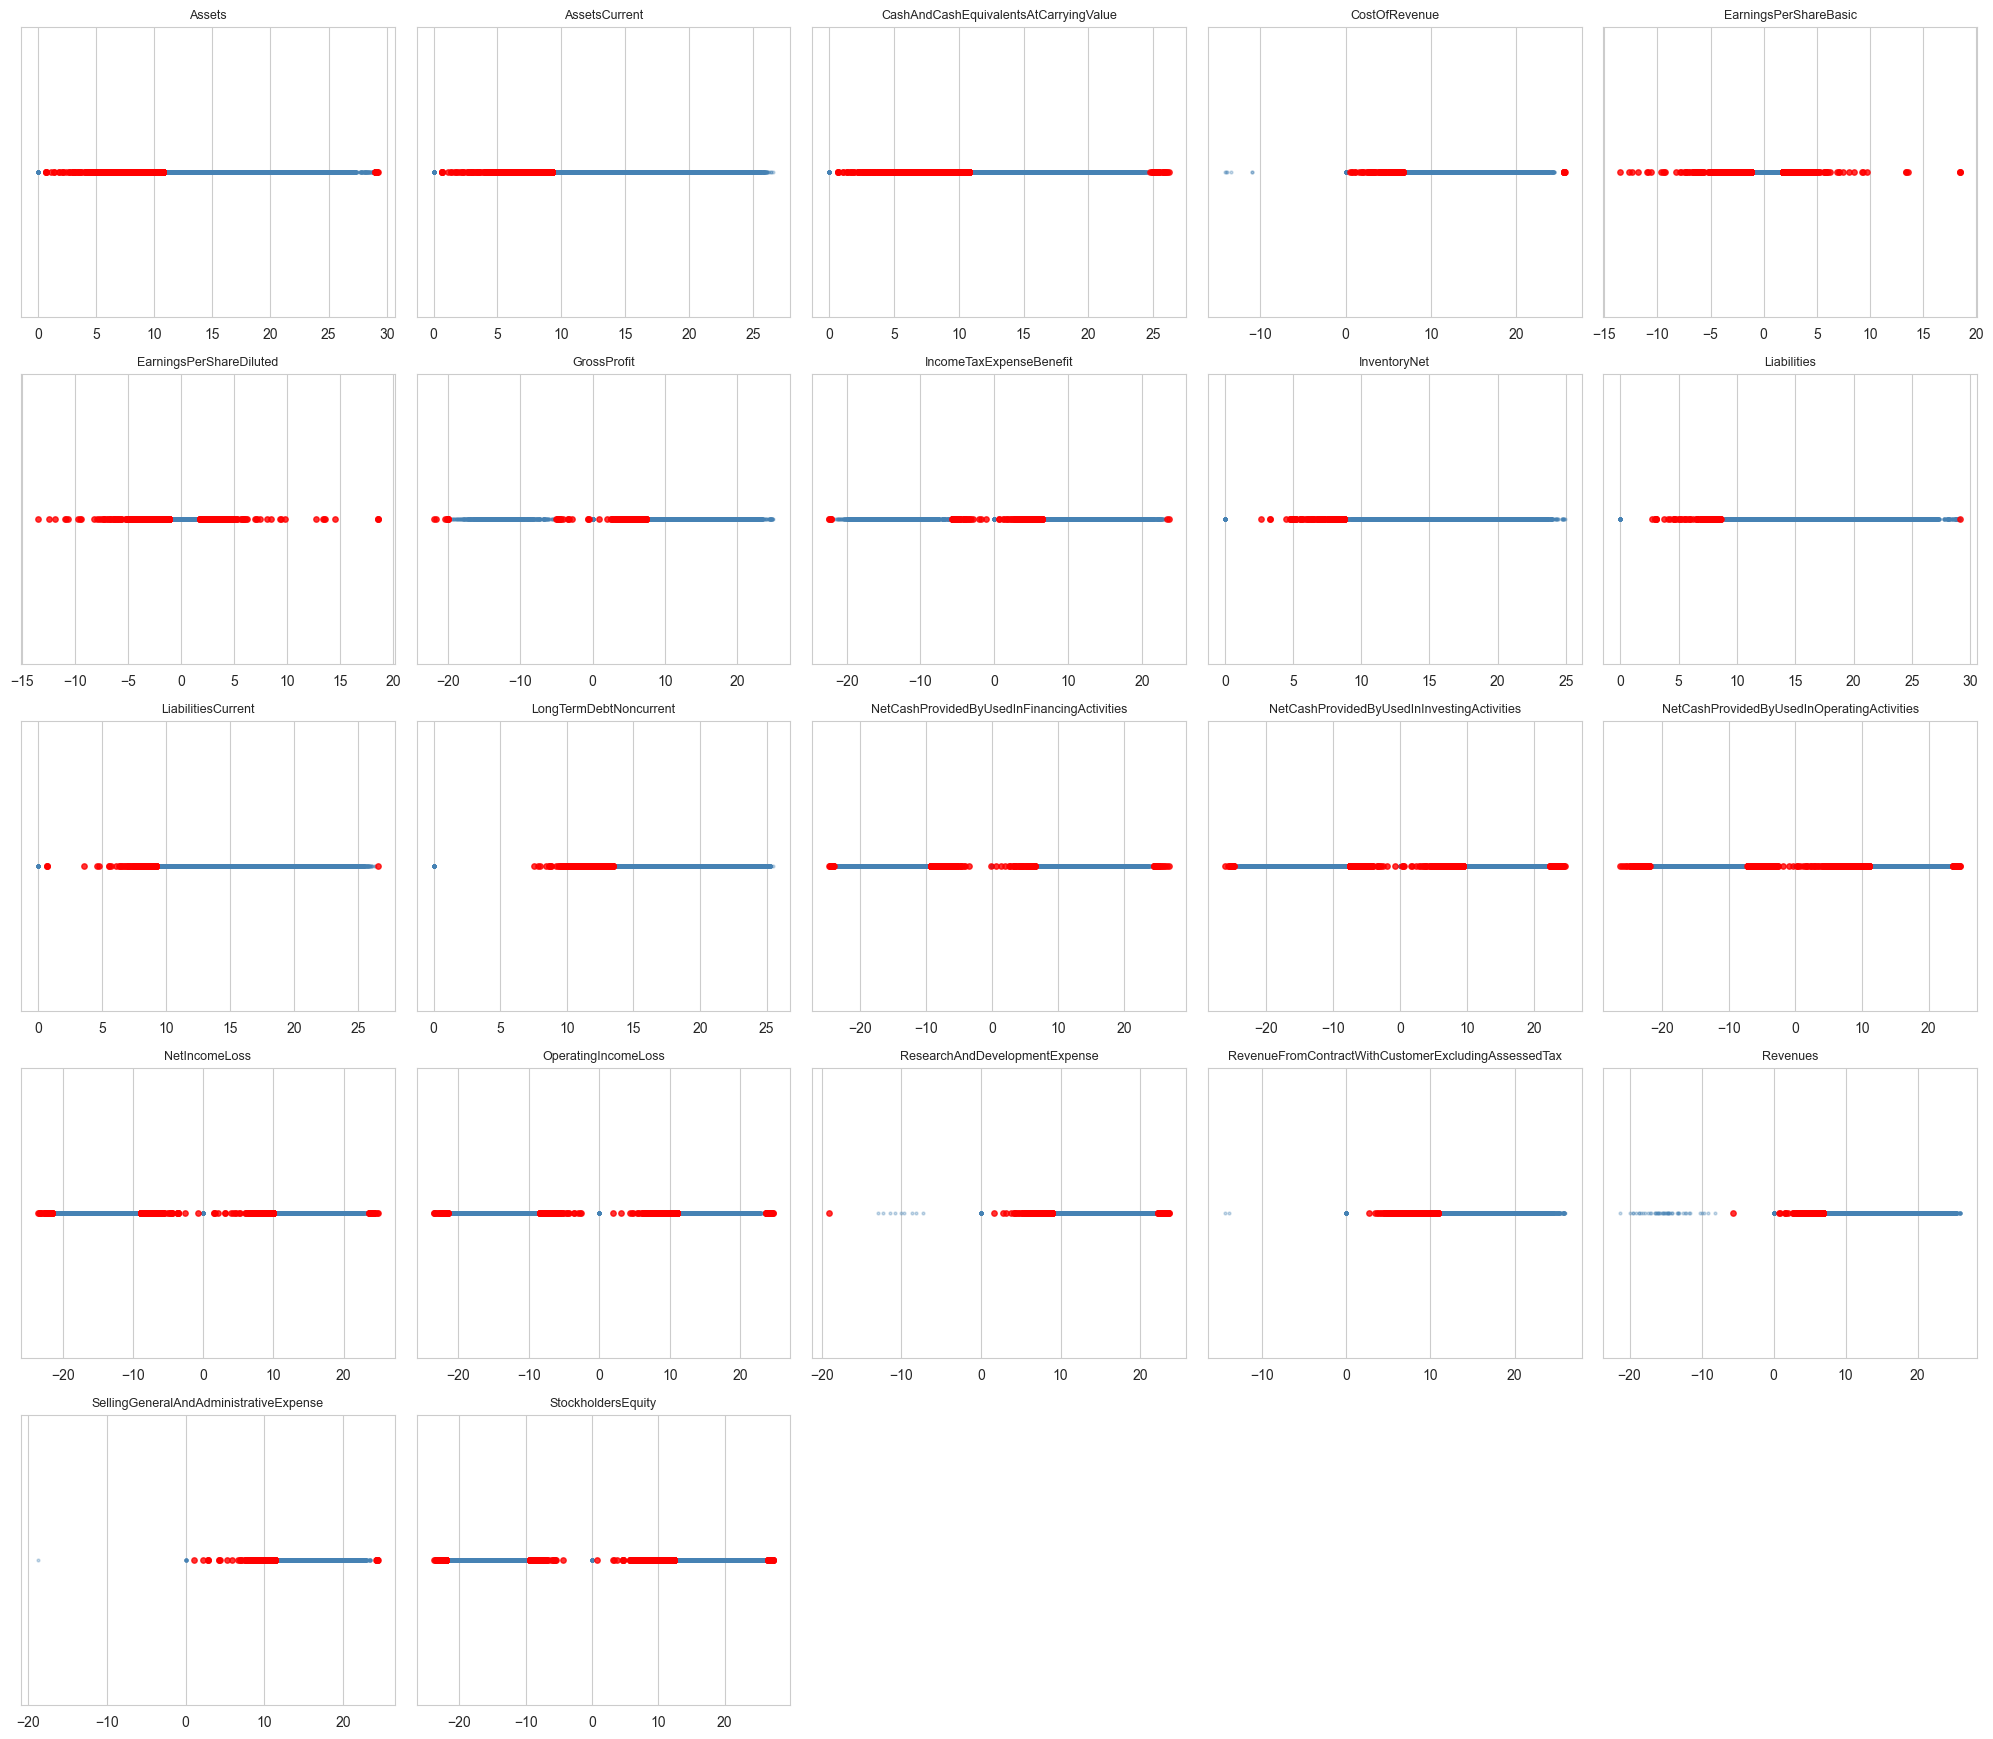

[SAVED] reports\figures\outliers_detection_statistical_charts\03_visual_vs_statistical_crosscheck.png
Red = IQR-method se statistically flagged outliers.


In [12]:
fig, axes = make_grid(len(metric_cols), cols=5)
for ax, col in zip(axes, metric_cols):
    data = df[col].dropna()
    transformed = signlog(data)
    is_outlier = df.loc[data.index, f"{col}_is_outlier_iqr"]

    ax.scatter(transformed[~is_outlier], np.zeros((~is_outlier).sum()), s=4, alpha=0.3, color="steelblue")
    ax.scatter(transformed[is_outlier], np.zeros(is_outlier.sum()), s=15, alpha=0.8, color="red")
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])

plt.tight_layout()
plt.savefig(STATISTICAL_DIR / "03_visual_vs_statistical_crosscheck.png", dpi=120)
plt.show()
print(f"[SAVED] {STATISTICAL_DIR / '03_visual_vs_statistical_crosscheck.png'}")
print("Red = IQR-method se statistically flagged outliers.")

---
# PART 4 -- EPS Error-Correction (sirf yahi 'treatment' hai is notebook mein)

**ZAROORI FARQ:** Ye winsorization/capping NAHI hai -- ye genuinely IMPOSSIBLE
values (XBRL tagging errors, jaise $108 million/share) ko NaN karna hai. EPS khud
kisi doosre ratio ka denominator nahi banta, isliye ise fix karna kisi aur ratio ko
distort nahi karta (JPMorgan-Assets jaisa cross-contamination risk yahan nahi hai).

In [13]:
print("EPS implausible values (data-errors) ko NaN kar rahe hain...\n")
for col in EPS_COLS:
    implausible = df[col].abs() > EPS_PLAUSIBILITY_LIMIT
    n_implausible = implausible.sum()
    print(f"  {col}: {n_implausible} implausible values (|value| > {EPS_PLAUSIBILITY_LIMIT}) -> NaN")
    df.loc[implausible, col] = np.nan

EPS implausible values (data-errors) ko NaN kar rahe hain...

  EarningsPerShareBasic: 36 implausible values (|value| > 1000) -> NaN
  EarningsPerShareDiluted: 36 implausible values (|value| > 1000) -> NaN


---
# Save (`05_outliers_flagged.parquet`)

**ZAROORI:** Raw dollar-columns (Assets, Liabilities, Revenues, NetIncomeLoss...)
BILKUL UNCHANGED hain (sirf EPS fix hui) -- sirf naye FLAG-columns add hue hain.
Row count `04` jaisa hi rehna chahiye.

In [14]:
df.to_parquet(OUTPUT_PATH, index=False)
print(f"[SAVED] {OUTPUT_PATH}")
print(f"Shape: {df.shape}")

[SAVED] data\processed\05_outliers_flagged.parquet
Shape: (58241, 79)


## Sanity Checks

In [15]:
df_before = pd.read_parquet(INPUT_PATH)
print(f"Row count before (04 output): {len(df_before)}")
print(f"Row count after (05 output):  {len(df)}")
assert len(df_before) == len(df), "MASLA: row count badal gaya! 05 sirf flag/EPS-fix karti hai."
print("[OK] Row count same hai.")

# Verify raw (non-EPS) columns bilkul unchanged hain
non_eps_metric_cols = [c for c in metric_cols if c not in EPS_COLS]
unchanged = all(df_before[c].equals(df[c]) for c in non_eps_metric_cols)
print(f"\n[{'OK' if unchanged else 'MASLA'}] Non-EPS raw dollar-columns {'UNCHANGED hain (jaisa hona chahiye)' if unchanged else 'BADAL GAYE HAIN -- ye galat hai!'}")

n_iqr_flag_cols = len([c for c in df.columns if c.endswith('_is_outlier_iqr')])
n_modz_flag_cols = len([c for c in df.columns if c.endswith('_is_outlier_modz')])
print(f"\nIQR flag columns added: {n_iqr_flag_cols}")
print(f"ModZ flag columns added: {n_modz_flag_cols}")
assert n_iqr_flag_cols == n_modz_flag_cols == 22, "MASLA: saare 22 columns cover nahi hue!"
print("[OK] Saare 22 metric columns par dono statistical methods lagi hain.")

print(f"\nVisual charts saved: {len(list(VISUAL_DIR.glob('*.png')))} files")
print(f"Statistical charts saved: {len(list(STATISTICAL_DIR.glob('*.png')))} files")

print("\n--- REMINDER ---")
print("Raw dollar-columns yahan CAP nahi hui -- 08 mein ratios TRUE values se banenge,")
print("phir un RATIOS par treatment (winsorization) hogi -- raw dollars par nahi.")

Row count before (04 output): 58241
Row count after (05 output):  58241
[OK] Row count same hai.

[OK] Non-EPS raw dollar-columns UNCHANGED hain (jaisa hona chahiye)

IQR flag columns added: 22
ModZ flag columns added: 22
[OK] Saare 22 metric columns par dono statistical methods lagi hain.

Visual charts saved: 2 files
Statistical charts saved: 3 files

--- REMINDER ---
Raw dollar-columns yahan CAP nahi hui -- 08 mein ratios TRUE values se banenge,
phir un RATIOS par treatment (winsorization) hogi -- raw dollars par nahi.
